# Solution: Max of List (Monthly Algorithmic Challenge, April 2026)

Two attention-only models, no MLPs, no LayerNorm, learned positional embeddings, $d_{\text{model}} = 64$, four heads per layer, $d_{\text{head}} = 16$.

| | Model 1a | Model 1b |
|---|---|---|
| numbers | 0 to 9, one token each | 0 to 99, two digit tokens each |
| input | $[\mathrm{BOS}]\ n_1\ [\mathrm{SEP}]\ n_2 \cdots n_5\ [\mathrm{ANS}]$ | $[\mathrm{BOS}]\ t_1 o_1\ [\mathrm{SEP}]\ t_2 o_2 \cdots t_5 o_5\ [\mathrm{ANS}]$ |
| output | the max at $\mathrm{ANS}$, then $\mathrm{EOS}$ | tens digit at $\mathrm{ANS}$, then ones digit, then $\mathrm{EOS}$ |
| layers | 1 | 2 |

**Notation.** $E_t$ is the embedding of token $t$, $P_j$ the positional embedding of position $j$, and the residual at position $j$ starts as $r_j = E_{x_j} + P_j$. A head $h$ in layer $L$ produces, at query position $i$, the weights $A_{ij} = \mathrm{softmax}_j\big(q_i \cdot k_j / 4\big)$ over $j \le i$ and the output $\Delta_i = \sum_j A_{ij} W_{OV} r_j$ with $W_{OV} = W_O^{(h)} W_V^{(h)}$, which is added to the residual. $u_t$ is the unembedding row of token $t$ and $\ell_t = u_t \cdot r$ its logit at the answer position. "Ablating a head" below means replacing its output by zero at every position.

## The two algorithms in one paragraph each

**Model 1a.** One head's attention score from $\mathrm{ANS}$ to a number token rises with the number's value (about 4 nats per unit), so the softmax puts essentially all its weight on copies of the maximum. Ties between copies are harmless because copies carry the same vector. The readout is distributed: each head's output lands on a single fixed direction in logit space (its OV path into the ten answer logits is rank 1), scaled by an amount that depends on the attended token. Three of the four heads sit on $\mathrm{ANS}$ itself for small maxima and provide fixed biases that favour small answers; head 3's ramp, whose scale grows with the maximum, walks the winning answer up from 2 to 6. For 7, 8, 9 head 3's scale is no longer monotone, and heads 2 (which attends to values $\ge 7$) and 0 (which attends to 9) supply the missing separation.

**Model 1b.** The tens digit is model 1a again: layer-0 head 1 attends from $\mathrm{ANS}$ to the largest tens-digit token. The ones digit needs both layers. In layer 0, head 3 at every ones-digit position attends to the tens digit of the same number (the previous token, 90% of its weight) and copies it, so after layer 0 each ones position carries the whole two-digit number. At the ones output position, layer-1 heads 0 and 3 score every ones position by about $16 \times (\text{stored tens digit}) + 1.8 \times (\text{ones digit})$, a linear stand-in for the number's magnitude that respects lexicographic order, attend to the largest, and copy its ones digit out. The fed-back tens digit sharpens this score but does no matching. A one-layer model cannot do the ones digit because at the output position it can only score a ones-digit position by that position's own token; the tens digit of the same number sits somewhere it cannot see.

## Setup

In [1]:
%pip install -q torch einops huggingface_hub matplotlib

In [2]:
import json, importlib
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

torch.set_grad_enabled(False)
np.set_printoptions(precision=2, suppress=True, linewidth=220)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

def load(which):
    repo = f"andyrdt/04_2026_puzzle_1{which}"
    p = hf_hub_download(repo, "model.py")
    spec = importlib.util.spec_from_file_location(f"model_{which}", p)
    mod = importlib.util.module_from_spec(spec); spec.loader.exec_module(mod)
    cfg = json.loads(Path(hf_hub_download(repo, "config.json")).read_text())
    m = mod.AttentionOnlyTransformer.from_config(cfg["model"])
    m.load_state_dict(torch.load(hf_hub_download(repo, "model.pt"), map_location="cpu", weights_only=True))
    return m.eval()

BOS, SEP, ANS, EOS = 10, 11, 12, 13
NAMES = {10: "BOS", 11: "SEP", 12: "ANS", 13: "EOS"}
D = 16
label = lambda t: NAMES.get(t, str(t))

def tok1(nums):
    out = [BOS]
    for i, n in enumerate(nums):
        out.append(n)
        if i < len(nums) - 1: out.append(SEP)
    return out + [ANS]

def tok2(nums):
    out = [BOS]
    for i, n in enumerate(nums):
        out += [n // 10, n % 10]
        if i < len(nums) - 1: out.append(SEP)
    return out + [ANS]

def run_with_ablation(m, x, zero=()):
    # zero: set of (layer, head) whose output is replaced by zero at every position
    E, P, U = m.tok_embed.weight, m.pos_embed.weight, m.unembed.weight
    b, s = x.shape
    h = E[x] + P[torch.arange(s)]
    mask = torch.tril(torch.ones(s, s)).unsqueeze(0)
    for L, layer in enumerate(m.layers):
        outs = []
        for hi, head in enumerate(layer.heads):
            o, _ = head(h, mask)
            if (L, hi) in zero: o = torch.zeros_like(o)
            outs.append(o)
        h = h + layer.W_O(torch.cat(outs, -1))
    return h[:, -1] @ U.T

def logit_components(m, x):
    # per-component logit vectors (over answers 0..9) at the last position: direct path and every head
    E, P, U = m.tok_embed.weight, m.pos_embed.weight, m.unembed.weight
    b, s = x.shape
    h = E[x] + P[torch.arange(s)]
    mask = torch.tril(torch.ones(s, s)).unsqueeze(0)
    comps = {"direct": h[:, -1] @ U[:10].T}
    for L, layer in enumerate(m.layers):
        outs = []
        for hi, head in enumerate(layer.heads):
            o, _ = head(h, mask); outs.append(o)
            comps[f"L{L}H{hi}"] = (o[:, -1] @ layer.W_O.weight[:, hi * D:(hi + 1) * D].T) @ U[:10].T
        h = h + layer.W_O(torch.cat(outs, -1))
    return comps

m1 = load("a"); m2 = load("b")
print("model 1a parameters:", sum(p.numel() for p in m1.parameters()), "  model 1b parameters:", sum(p.numel() for p in m2.parameters()))

model 1a parameters: 18944   model 1b parameters: 35712


---
# Model 1a: max of five digits, one layer

## 1a.1 Accuracy

In [3]:
rng = np.random.default_rng(0)
lists1 = rng.integers(0, 10, size=(20000, 5))
X1 = torch.tensor([tok1(l.tolist()) for l in lists1]); MAX1 = torch.tensor(lists1.max(1))
logits1, attn1 = m1(X1)
print("max accuracy:", (logits1[:, -1, :10].argmax(-1) == MAX1).float().mean().item())
X1e = torch.cat([X1, MAX1[:, None]], 1); lg, _ = m1(X1e)
print("EOS predicted after the answer:", (lg[:, -1].argmax(-1) == EOS).float().mean().item())

max accuracy: 1.0


EOS predicted after the answer: 1.0


## 1a.2 Attention: scores that rise with the value find the maximum

The query is $\mathrm{ANS}$ at position 10. Because the positional part of a number token's key is nearly the same at all five number positions, the score from $\mathrm{ANS}$ to a number token depends only on the token. The table lists $q_{\mathrm{ANS}} \cdot k_n / 4$ for each digit $n$, and the score on $\mathrm{ANS}$ itself, for each head.

- **Head 3** rises monotonically from $-21.6$ (digit 0) to $+24.1$ (digit 9), with gaps of 3.7 to 9 nats, and every non-number key is far below. The softmax therefore lands on the largest digit present: 99.5% of its weight on copies of the maximum.
- **Head 2** is only above its own $\mathrm{ANS}$ key for digits 7, 8, 9. It attends to the maximum when the maximum is at least 7, and to $\mathrm{ANS}$ otherwise.
- **Head 0** is above its $\mathrm{ANS}$ key only for digit 9 (and partly 8).
- **Head 1** attends to $\mathrm{ANS}$ always.

Copies of the maximum share the weight, and since every copy carries the same vector $E_n + P_j$ (up to the small positional part), a tie changes nothing downstream.

score from ANS to digit n (mean over the five number positions), then to its own ANS key
  H0: 0: -15.8 1:  -8.1 2:  -4.9 3:  -6.0 4:  -7.8 5:  -9.8 6: -13.5 7:   4.0 8:   6.1 9:  11.4   ANS self:    7.9   SEP:  -19.4   (std across positions 0.02)
  H1: 0:  -5.0 1:  -1.3 2:  -2.4 3:  -9.0 4: -16.4 5: -25.5 6: -37.5 7:  -7.8 8: -15.8 9: -13.5   ANS self:   25.0   SEP:  -17.4   (std across positions 0.09)
  H2: 0: -16.5 1:  -9.1 2:  -5.7 3:  -5.3 4:  -5.6 5:  -6.3 6:  -8.0 7:   5.8 8:   8.9 9:  13.7   ANS self:    2.8   SEP:  -18.7   (std across positions 0.01)
  H3: 0: -21.6 1: -12.6 2:  -7.8 3:  -3.7 4:   0.3 5:   4.4 6:   8.3 7:  12.1 8:  18.9 9:  24.1   ANS self:  -12.1   SEP:  -20.1   (std across positions 0.01)

attention from ANS, mean weight on: copies of the max | other numbers | ANS itself
  H0: 0.445 | 0.003 | 0.552
  H1: 0.000 | 0.000 | 1.000
  H2: 0.817 | 0.007 | 0.177
  H3: 0.995 | 0.005 | 0.000


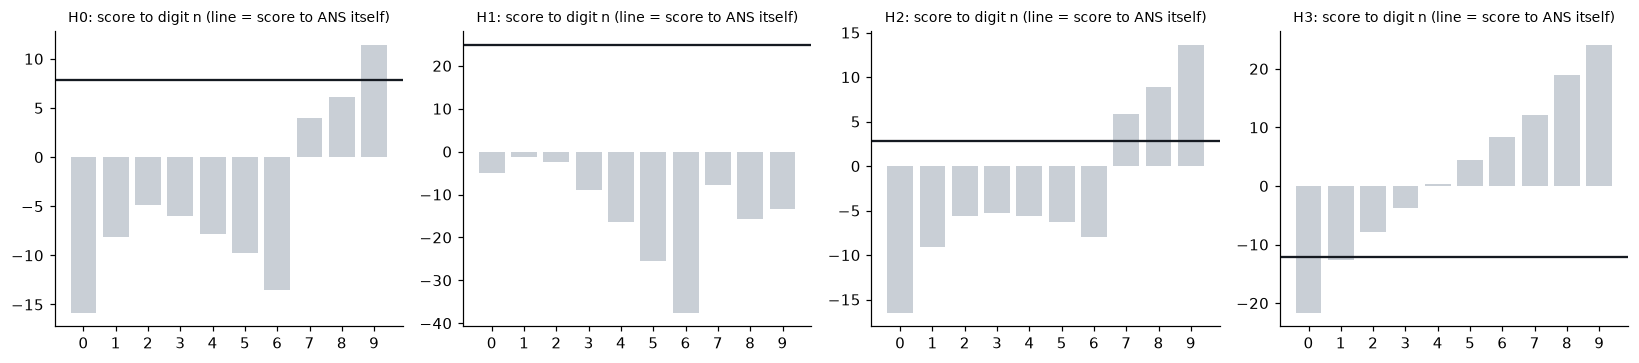

In [4]:
E, P, U = m1.tok_embed.weight, m1.pos_embed.weight, m1.unembed.weight
L = m1.layers[0]
NUMPOS = [1, 3, 5, 7, 9]
q_res = E[ANS] + P[10]
print("score from ANS to digit n (mean over the five number positions), then to its own ANS key")
for h in range(4):
    hd = L.heads[h]; q = hd.W_Q(q_res)
    row = [float(torch.stack([hd.W_K(E[n] + P[p]) for p in NUMPOS]).mean(0) @ q / 4) for n in range(10)]
    spread = np.mean([float((torch.stack([hd.W_K(E[n] + P[p]) for p in NUMPOS]) @ q / 4).std()) for n in range(10)])
    print(f"  H{h}: " + " ".join(f"{n}:{v:6.1f}" for n, v in enumerate(row)) + f"   ANS self: {float(hd.W_K(E[ANS]+P[10]) @ q / 4):6.1f}   SEP: {float(hd.W_K(E[SEP]+P[4]) @ q / 4):6.1f}   (std across positions {spread:.2f})")

A = attn1[0][:, :, -1, :]
is_max = X1[:, NUMPOS] == MAX1[:, None]
print("\nattention from ANS, mean weight on: copies of the max | other numbers | ANS itself")
for h in range(4):
    a = A[:, h]
    print(f"  H{h}: {(a[:, NUMPOS] * is_max).sum(-1).mean():.3f} | {(a[:, NUMPOS] * ~is_max).sum(-1).mean():.3f} | {a[:, 10].mean():.3f}")

fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))
for h in range(4):
    hd = L.heads[h]; q = hd.W_Q(q_res)
    row = [float(torch.stack([hd.W_K(E[n] + P[p]) for p in NUMPOS]).mean(0) @ q / 4) for n in range(10)]
    axes[h].bar(range(10), row, color="#c9cfd6")
    axes[h].axhline(float(hd.W_K(E[ANS] + P[10]) @ q / 4), color="#151a21", lw=1.5)
    axes[h].set_title(f"H{h}: score to digit n (line = score to ANS itself)", fontsize=9); axes[h].set_xticks(range(10))
plt.tight_layout(); plt.show()

## 1a.3 Readout: rank-1 heads and an upper envelope

Each head's OV path into the ten answer logits, $n \mapsto u_{0..9} \cdot W_{OV}(E_n + P_j)$, has one non-zero singular value: the head writes a fixed 10-vector of logits $g_h$, scaled by a number $c_h(n)$ that depends on the attended token. Head 3's direction $g_3$ is a ramp that rewards larger answers up to 6, and its scale $c_3(n)$ grows with $n$ for $n = 2, \dots, 6$ and is not monotone beyond.

Put together, for a true maximum $M$:

- $M \le 6$: heads 0, 1, 2 attend to $\mathrm{ANS}$ and contribute fixed vectors that favour answers 2 and 3. Head 3 contributes $c_3(M)\, g_3$. As $c_3(M)$ grows with $M$, the winner moves along the ramp: 2, 3, 4, 5, 6. The logit of answer $k$ is $b_k + c_3(M)\, g_3[k]$ with $b_k$ decreasing and $g_3[k]$ increasing in $k$, so which $k$ is on top is a monotone function of $c_3(M)$.
- $M \in \{7, 8, 9\}$: head 3 attending to 7, 8 or 9 still ranks 6 highest on its own. Head 2 now attends to the maximum and adds a vector that favours 8 and 9; for $M = 9$ head 0 adds one that favours 9. Their sum with head 3 puts $M$ on top.

The table shows the mean logit vector of every component for each $M$, and the minimum margin of the correct answer over the runner-up.

In [5]:
def ov(layer, h): return layer.W_O.weight[:, h * D:(h + 1) * D] @ layer.heads[h].W_V.weight
print("singular values of each head's OV path (attended digit -> ten answer logits):")
for h in range(4):
    M = torch.stack([U[:10] @ (ov(L, h) @ (E[n] + P[5])) for n in range(10)])
    sv = torch.linalg.svdvals(M)
    print(f"  H{h}: {sv[:3].numpy().round(1)}")
Mh3 = torch.stack([U[:10] @ (ov(L, 3) @ (E[n] + P[5])) for n in range(10)])
u_, s_, vh = torch.linalg.svd(Mh3)
g3 = vh[0] * torch.sign(vh[0][6]); c3 = Mh3 @ g3
print("head 3 direction g3 over answers 0..9:", (g3 / g3.abs().max()).numpy().round(2))
print("head 3 scale c3(n) for attended digit n:", c3.numpy().round(0))

comps = logit_components(m1, X1)
total = sum(comps.values())
print("\nmean logit vector per component for each true max M; last column = min margin of M over the runner-up")
for M in range(2, 10):
    sel = MAX1 == M
    if sel.sum() < 5: continue
    print(f"\n  M = {M}  (n = {int(sel.sum())})")
    for name, c in comps.items():
        row = c[sel].mean(0)
        print(f"    {name:7s}: " + " ".join(f"{v:7.1f}" for v in row.tolist()) + f"   argmax {int(row.argmax())}")
    row = total[sel].mean(0); top2 = total[sel].topk(2, dim=-1).values
    print(f"    {'total':7s}: " + " ".join(f"{v:7.1f}" for v in row.tolist()) + f"   argmax {int(row.argmax())}   min margin {(top2[:, 0] - top2[:, 1]).min():.1f}")

singular values of each head's OV path (attended digit -> ten answer logits):
  H0: [220.2   0.4   0. ]
  H1: [64.6  0.8  0. ]
  H2: [283.4   0.2   0.1]
  H3: [1016.3    0.5    0.1]
head 3 direction g3 over answers 0..9: [-1.   -0.77 -0.5  -0.17  0.16  0.44  0.67  0.4   0.62  0.6 ]
head 3 scale c3(n) for attended digit n: [-36. -63. -37. 109. 266. 459. 705. 162. 338. 310.]



mean logit vector per component for each true max M; last column = min margin of M over the runner-up

  M = 2  (n = 46)
    direct :    -2.2    -1.0    -0.1     0.7     1.3     1.6     1.4     2.3     1.9     1.0   argmax 7
    L0H0   :    17.1    45.0    56.0    56.2    43.6    22.6   -15.3    32.2    -3.1   -39.9   argmax 3
    L0H1   :    -4.0     6.5    12.2    15.9    14.8    11.5     1.9    15.2     6.3    -4.3   argmax 3
    L0H2   :    51.8    68.3    69.2    59.1    40.0     9.6   -15.5   -14.8   -37.6   -59.7   argmax 2
    L0H3   :    22.5    17.4    11.3     3.9    -3.5    -9.9   -15.2    -9.2   -14.1   -13.8   argmax 0
    total  :    85.3   136.1   148.6   135.8    96.2    35.5   -42.7    25.6   -46.8  -116.8   argmax 2   min margin 12.0

  M = 3  (n = 187)
    direct :    -2.2    -1.0    -0.1     0.7     1.3     1.6     1.4     2.3     1.9     1.0   argmax 7
    L0H0   :    17.1    45.0    56.0    56.2    43.6    22.6   -15.3    32.2    -3.1   -39.9   argmax 3
    L0H1

## 1a.4 Ablations

Zeroing a head at all positions and reading which maxima survive matches the division of labour above: head 1 is never needed; without head 3 only $M = 2$ and $M = 9$ survive; without head 2 the range 3 to 5 and 9 break; without head 0 the values 4, 5, 7, 9 break (its fixed $\mathrm{ANS}$ vector is part of the bias that the ramp is calibrated against). Head 3 alone gets only $M = 6$ right.

In [6]:
print(f"{'zeroed heads':16s} {'acc':>6s}   accuracy by true max M")
for zero in [(), ((0, 1),), ((0, 3),), ((0, 2),), ((0, 0),), ((0, 0), (0, 1), (0, 2))]:
    lg = run_with_ablation(m1, X1, zero)
    ok = lg[:, :10].argmax(-1) == MAX1
    by = " ".join(f"{M}:{ok[MAX1 == M].float().mean():.2f}" for M in range(2, 10))
    name = "none" if not zero else ", ".join(f"H{h}" for _, h in zero)
    print(f"{name:16s} {ok.float().mean():6.3f}   {by}")

zeroed heads        acc   accuracy by true max M


none              1.000   2:1.00 3:1.00 4:1.00 5:1.00 6:1.00 7:1.00 8:1.00 9:1.00


H1                1.000   2:1.00 3:1.00 4:1.00 5:1.00 6:1.00 7:1.00 8:1.00 9:1.00


H3                0.414   2:1.00 3:0.00 4:0.00 5:0.00 6:0.00 7:0.03 8:0.00 9:1.00


H2                0.516   2:1.00 3:0.00 4:0.00 5:0.00 6:1.00 7:1.00 8:1.00 9:0.00


H0                0.369   2:1.00 3:1.00 4:0.00 5:0.00 6:1.00 7:0.00 8:1.00 9:0.00


H0, H1, H2        0.091   2:0.00 3:0.00 4:0.00 5:0.00 6:1.00 7:0.00 8:0.00 9:0.00


---
# Model 1b: max of five two-digit numbers, two layers, digit tokens

## 1b.1 Accuracy and the shape of the computation

The model answers in two steps. At $\mathrm{ANS}$ (position 15) it emits the tens digit $T$ of the maximum; that digit is appended as the input at position 16, where the model emits the ones digit $O$; then $\mathrm{EOS}$. Positions: $\mathrm{BOS}$ at 0, tens digits at 1, 4, 7, 10, 13, ones digits at 2, 5, 8, 11, 14, $\mathrm{SEP}$ at 3, 6, 9, 12, $\mathrm{ANS}$ at 15.

In [7]:
rng = np.random.default_rng(1)
lists2 = rng.integers(0, 100, size=(6000, 5))
X2 = torch.tensor([tok2(l.tolist()) for l in lists2]); MAX2 = torch.tensor(lists2.max(1)); T2, O2 = MAX2 // 10, MAX2 % 10
logits_t, attn_t = m2(X2)
X2b = torch.cat([X2, T2[:, None]], 1); logits_o, attn_o = m2(X2b)
X2c = torch.cat([X2b, O2[:, None]], 1); logits_e, _ = m2(X2c)
print("tens accuracy:", (logits_t[:, -1, :10].argmax(-1) == T2).float().mean().item())
print("ones accuracy:", (logits_o[:, -1, :10].argmax(-1) == O2).float().mean().item())
print("EOS accuracy :", (logits_e[:, -1].argmax(-1) == EOS).float().mean().item())

TENS, ONES, SEPS = [1, 4, 7, 10, 13], [2, 5, 8, 11, 14], [3, 6, 9, 12]
nums = X2[:, TENS] * 10 + X2[:, ONES]
is_maxnum = nums == MAX2[:, None]; is_maxtens = X2[:, TENS] == T2[:, None]
def report(A, title):
    print(f"\n{title}")
    print(f"  {'head':5s} {'BOS':>5s} {'tens':>5s} {'(max num)':>10s} {'ones':>5s} {'(max num)':>10s} {'SEP':>5s} {'ANS':>5s} {'T':>5s}")
    for h in range(4):
        a = A[:, h]
        print(f"  H{h}    {a[:,0].mean():5.2f} {a[:,TENS].sum(-1).mean():5.2f} {(a[:,TENS]*is_maxnum).sum(-1).mean():10.2f} {a[:,ONES].sum(-1).mean():5.2f} {(a[:,ONES]*is_maxnum).sum(-1).mean():10.2f} {a[:,SEPS].sum(-1).mean():5.2f} {a[:,15].mean():5.2f} {a[:,16].mean() if a.shape[1] > 16 else float('nan'):5.2f}")
report(attn_t[0][:, :, 15, :], "Layer 0, query = ANS (tens step): mean attention mass by key group")
report(attn_t[1][:, :, 15, :], "Layer 1, query = ANS (tens step)")
report(attn_o[0][:, :, 16, :], "Layer 0, query = fed-back tens digit (ones step)")
report(attn_o[1][:, :, 16, :], "Layer 1, query = fed-back tens digit (ones step)")

tens accuracy: 1.0
ones accuracy: 1.0
EOS accuracy : 1.0

Layer 0, query = ANS (tens step): mean attention mass by key group
  head    BOS  tens  (max num)  ones  (max num)   SEP   ANS     T
  H0     0.00  0.01       0.01  0.00       0.00  0.00  0.98   nan
  H1     0.00  1.00       0.84  0.00       0.00  0.00  0.00   nan
  H2     0.00  0.14       0.02  0.12       0.02  0.03  0.71   nan
  H3     0.01  0.15       0.02  0.13       0.03  0.05  0.65   nan

Layer 1, query = ANS (tens step)
  head    BOS  tens  (max num)  ones  (max num)   SEP   ANS     T
  H0     0.96  0.02       0.00  0.00       0.00  0.00  0.02   nan
  H1     0.00  0.00       0.00  0.00       0.00  0.00  1.00   nan
  H2     0.19  0.16       0.03  0.07       0.02  0.04  0.54   nan
  H3     0.77  0.01       0.00  0.00       0.00  0.00  0.21   nan

Layer 0, query = fed-back tens digit (ones step)
  head    BOS  tens  (max num)  ones  (max num)   SEP   ANS     T
  H0     0.01  0.17       0.05  0.05       0.01  0.03  0.68  0.05

Reading the four tables:

- **Tens step.** Layer-0 head 1 puts all its weight on tens-digit positions, 95% of it on the maximal tens digit. Layer 1 at $\mathrm{ANS}$ attends to $\mathrm{BOS}$ and to $\mathrm{ANS}$ itself, which are fixed positions; it acts as biases and as an extra linear map on what layer 0 wrote at $\mathrm{ANS}$.
- **Ones step.** Layer-1 heads 0 and 3 put all their weight on ones-digit positions, 99% of it on the ones digit of the maximum number. That is the interesting part: how do they know which ones digit belongs to the largest number?

## 1b.2 Layer 0 composes each number at its ones-digit position

Layer-0 head 3, queried from a ones-digit position, attends to tens-digit positions, with 90% of its weight on the immediately preceding one, the tens digit of the same number. After layer 0, the residual at a ones position therefore contains its own digit $o$ plus $W_{OV}^{(0,3)}(E_t + P_{j-1})$, a copy of the tens digit $t$.

In [8]:
E2, P2, U2 = m2.tok_embed.weight, m2.pos_embed.weight, m2.unembed.weight
L0, L1 = m2.layers
A0 = attn_t[0]
print("layer-0 attention from ones-digit positions: mean weight on the previous position (own tens digit), on itself, on BOS")
for h in range(4):
    own = torch.stack([A0[:, h, p, p - 1] for p in ONES], 1).mean(); me = torch.stack([A0[:, h, p, p] for p in ONES], 1).mean(); b = torch.stack([A0[:, h, p, 0] for p in ONES], 1).mean()
    print(f"  L0H{h}: own tens {own:.2f}   self {me:.2f}   BOS {b:.2f}")
print("\nL0H3 score from the ones position 14 to every earlier position (averaged over digit tokens):")
hd = L0.heads[3]
row = []
for j in range(15):
    toks = [BOS] if j == 0 else ([SEP] if j in SEPS else list(range(10)))
    row.append(np.mean([float(hd.W_K(E2[t] + P2[j]) @ hd.W_Q(E2[o] + P2[14]) / 4) for t in toks for o in range(10)]))
print("  " + " ".join(f"{j}:{v:5.1f}" for j, v in enumerate(row)))
print("  (positions 13, 10, 7, 4, 1 are tens digits; the nearest one scores highest)")

layer-0 attention from ones-digit positions: mean weight on the previous position (own tens digit), on itself, on BOS
  L0H0: own tens 0.06   self 0.45   BOS 0.19
  L0H1: own tens 0.02   self 0.43   BOS 0.06
  L0H2: own tens 0.12   self 0.25   BOS 0.31
  L0H3: own tens 0.90   self 0.00   BOS 0.01

L0H3 score from the ones position 14 to every earlier position (averaged over digit tokens):
  0:  1.8 1: -0.9 2: -2.6 3: -1.7 4:  3.4 5: -1.4 6:  1.2 7:  6.5 8:  0.7 9:  4.9 10:  9.6 11:  2.9 12:  7.4 13: 13.5 14:  5.8
  (positions 13, 10, 7, 4, 1 are tens digits; the nearest one scores highest)


## 1b.3 Layer 1 scores each number by magnitude and attends to the largest

At the ones output position the query is built from the fed-back token $T$. Decompose the score that layer-1 head 0 gives to a ones position into the parts of that position's residual: the token and position themselves, and each layer-0 head's output there. Two facts come out.

1. **The copied tens digit dominates and the score is linear in it.** One unit of attention on a copied tens digit $t$ is worth about $16\,t$ nats, so a number with a larger tens digit beats any number with a smaller one regardless of the ones digits.
2. **The ones digit adds about 1.8 nats per unit** (through the token itself and through layer-0 head 2's output at that position), which breaks ties among numbers that share the maximal tens digit. The total range of the ones term (about 16 nats) is just below one step of the tens term, so the score respects lexicographic order.

So the score is, to a good approximation, $16 \cdot \text{tens} + 1.8 \cdot \text{ones} + \text{const}$, and the softmax over ones positions selects the largest number. The fed-back digit $T$ scales the slope (larger $T$, sharper attention) but there is no equality test against $T$: the score rises with the stored tens digit for every $T$. It does not need one, because $T$ is by definition the largest tens digit present.

In [9]:
def l0_parts(x):
    b, s = x.shape
    h = E2[x] + P2[torch.arange(s)]
    mask = torch.tril(torch.ones(s, s)).unsqueeze(0)
    parts, outs = {"token+pos": h}, []
    for hi, head in enumerate(L0.heads):
        o, _ = head(h, mask); outs.append(o)
        parts[f"L0H{hi}"] = o @ L0.W_O.weight[:, hi * D:(hi + 1) * D].T
    return h + L0.W_O(torch.cat(outs, -1)), parts

ov03 = L0.W_O.weight[:, 3 * D:4 * D] @ L0.heads[3].W_V.weight
hd = L1.heads[0]
x = torch.tensor([tok2([83, 12, 45, 60, 33]) + [8]]); r1, _ = l0_parts(x); q = hd.W_Q(r1[0, 16])
print("1. L1H0 score contributed by a full-strength copy of tens digit t at a ones position (query token 8):")
print("   " + " ".join(f"t={t}:{float(hd.W_K(ov03 @ (E2[t] + P2[1])) @ q / 4):6.1f}" for t in range(10)))

print("\n2. Fixed list [8o, 12, 45, 60, 33], ones digit o of the first number varied; L1H0 score at that number's ones position, split by source:")
print(f"   {'o':>2s} {'token+pos':>10s} {'L0H0':>7s} {'L0H1':>7s} {'L0H2':>7s} {'L0H3':>7s} {'total':>8s}")
for o in range(10):
    x = torch.tensor([tok2([80 + o, 12, 45, 60, 33]) + [8]]); r1, parts = l0_parts(x); q = hd.W_Q(r1[0, 16])
    sc = {k: float(hd.W_K(v[0, 2]) @ q / 4) for k, v in parts.items()}
    print(f"   {o:2d} {sc['token+pos']:10.2f} {sc['L0H0']:7.2f} {sc['L0H1']:7.2f} {sc['L0H2']:7.2f} {sc['L0H3']:7.2f} {float(hd.W_K(r1[0, 2]) @ q / 4):8.2f}")

print("\n3. Slope of the score in the stored tens digit, for each fed-back T (rows) and stored t (cols), from the L0H3 copy alone, L1H0:")
for T in range(0, 10, 3):
    qT = hd.W_Q(E2[T] + P2[16])
    print(f"   T={T}: " + " ".join(f"{float(torch.stack([hd.W_K(ov03 @ (E2[t] + P2[p - 1])) for p in ONES]).mean(0) @ qT / 4):6.1f}" for t in range(10)))

print("\n4. Constructed ties on the tens digit: attention of L1H0 / L1H3 over the five ones positions, and the prediction")
for nums_ in [[83, 87, 12, 45, 60], [90, 99, 95, 91, 93], [50, 51, 52, 53, 54], [39, 31, 30, 35, 12], [20, 20, 20, 20, 21]]:
    T = max(nums_) // 10; O = max(nums_) % 10
    x = torch.tensor([tok2(nums_) + [T]]); lg, at = m2(x)
    pred = int(lg[0, -1, :10].argmax())
    print(f"   {str(nums_):24s} max {max(nums_)}  pred {pred} {'ok' if pred == O else 'WRONG'}   H0: " + " ".join(f"{n%10}:{w:.2f}" for n, w in zip(nums_, at[1][0, 0, 16, ONES].tolist())) + "   H3: " + " ".join(f"{n%10}:{w:.2f}" for n, w in zip(nums_, at[1][0, 3, 16, ONES].tolist())))

rng = np.random.default_rng(4); n_ok = n_att = 0
for _ in range(2000):
    t = int(rng.integers(1, 10)); o1, o2 = rng.choice(10, size=2, replace=False)
    nums_ = [t * 10 + int(o1), t * 10 + int(o2)] + rng.integers(0, t * 10, size=3).tolist(); rng.shuffle(nums_)
    T = max(nums_) // 10; O = max(nums_) % 10
    x = torch.tensor([tok2(nums_) + [T]]); lg, at = m2(x)
    n_ok += int(lg[0, -1, :10].argmax()) == O
    n_att += int(at[1][0, 0, 16, ONES].argmax()) == nums_.index(max(nums_))
print(f"   2000 random lists whose top two numbers share the tens digit: ones accuracy {n_ok/2000:.3f}, L1H0 top weight on the max number {n_att/2000:.3f}")

1. L1H0 score contributed by a full-strength copy of tens digit t at a ones position (query token 8):
   t=0:  -2.2 t=1:  14.7 t=2:  30.8 t=3:  45.9 t=4:  61.1 t=5:  76.5 t=6:  91.7 t=7: 108.4 t=8: 126.3 t=9: 145.5

2. Fixed list [8o, 12, 45, 60, 33], ones digit o of the first number varied; L1H0 score at that number's ones position, split by source:
    o  token+pos    L0H0    L0H1    L0H2    L0H3    total
    0       2.22   -3.86    4.48   -0.13  124.76   127.47
    1       5.36   -3.12    2.39    2.11  124.48   131.23
    2       4.81   -4.03    5.26    1.32  124.36   131.72
    3       7.44   -3.65    2.78    4.25  125.43   136.25
    4       8.40   -3.92    3.32    4.53  125.05   137.39
    5      10.47   -3.69    0.51    5.72  125.84   138.86
    6       9.80   -4.06    2.54    6.06  125.48   139.82
    7      10.21   -4.08    1.86    7.11  126.13   141.23
    8      11.02   -3.82    0.84    8.74  126.38   143.16
    9      12.06   -3.10   -1.90   10.21  126.51   143.78

3. Slope

   2000 random lists whose top two numbers share the tens digit: ones accuracy 1.000, L1H0 top weight on the max number 0.991


## 1b.4 The tens step and the readouts

Layer-0 head 1's score from $\mathrm{ANS}$ to a tens-digit token rises by about 2.1 nats per unit and is far lower for the same token at a ones position, so it attends to the largest tens digit (the same mechanism as model 1a). As in model 1a, no single head's output has the right argmax on its own: the readout is a sum of low-rank head outputs plus fixed vectors from heads that sit on $\mathrm{BOS}$ or $\mathrm{ANS}$, whose total has the correct argmax with a margin of at least 4.5 logits on the tens step and 5.4 on the ones step.

In [10]:
hd = L0.heads[1]; q = hd.W_Q(E2[ANS] + P2[15])
print("L0H1 score from ANS to digit d at tens positions:", " ".join(f"{d}:{float(torch.stack([hd.W_K(E2[d]+P2[p]) for p in TENS]).mean(0) @ q / 4):5.1f}" for d in range(10)))
print("                     same digit at ones positions:", " ".join(f"{d}:{float(torch.stack([hd.W_K(E2[d]+P2[p]) for p in ONES]).mean(0) @ q / 4):5.1f}" for d in range(10)))
for step, xx, target, nm in [("tens", X2, T2, "T"), ("ones", X2b, O2, "O")]:
    comps = logit_components(m2, xx); total = sum(comps.values())
    print(f"\n{step} step: argmax of each component's mean logit vector per true digit, and min margin")
    for v in range(10):
        sel = target == v
        if sel.sum() < 5: continue
        top2 = total[sel].topk(2, dim=-1).values
        print(f"  {nm}={v}: " + " ".join(f"{k}:{int(c[sel].mean(0).argmax())}" for k, c in comps.items()) + f" | total {int(total[sel].mean(0).argmax())}  margin {(top2[:,0]-top2[:,1]).min():.1f}")

L0H1 score from ANS to digit d at tens positions: 0:  5.0 1:  7.4 2:  9.7 3: 11.8 4: 13.1 5: 14.7 6: 16.6 7: 19.0 8: 21.5 9: 23.7
                     same digit at ones positions: 0:-16.7 1:-14.3 2:-12.0 3: -9.9 4: -8.5 5: -7.0 6: -5.1 7: -2.6 8: -0.2 9:  2.0

tens step: argmax of each component's mean logit vector per true digit, and min margin
  T=2: direct:6 L0H0:6 L0H1:9 L0H2:6 L0H3:2 L1H0:0 L1H1:2 L1H2:3 L1H3:1 | total 2  margin 6.4
  T=3: direct:6 L0H0:6 L0H1:9 L0H2:6 L0H3:2 L1H0:5 L1H1:2 L1H2:3 L1H3:1 | total 3  margin 8.1
  T=4: direct:6 L0H0:6 L0H1:9 L0H2:6 L0H3:2 L1H0:6 L1H1:2 L1H2:3 L1H3:4 | total 4  margin 6.2
  T=5: direct:6 L0H0:6 L0H1:9 L0H2:6 L0H3:2 L1H0:6 L1H1:2 L1H2:3 L1H3:1 | total 5  margin 8.6
  T=6: direct:6 L0H0:6 L0H1:9 L0H2:6 L0H3:2 L1H0:6 L1H1:2 L1H2:3 L1H3:4 | total 6  margin 8.9
  T=7: direct:6 L0H0:6 L0H1:9 L0H2:6 L0H3:2 L1H0:6 L1H1:2 L1H2:3 L1H3:9 | total 7  margin 7.4
  T=8: direct:6 L0H0:6 L0H1:9 L0H2:6 L0H3:2 L1H0:6 L1H1:7 L1H2:3 L1H3:9 | total 8  marg


ones step: argmax of each component's mean logit vector per true digit, and min margin
  O=0: direct:3 L0H0:6 L0H1:2 L0H2:1 L0H3:2 L1H0:6 L1H1:0 L1H2:3 L1H3:9 | total 0  margin 6.5
  O=1: direct:3 L0H0:6 L0H1:2 L0H2:1 L0H3:2 L1H0:6 L1H1:0 L1H2:3 L1H3:9 | total 1  margin 5.6
  O=2: direct:2 L0H0:6 L0H1:2 L0H2:1 L0H3:2 L1H0:6 L1H1:0 L1H2:3 L1H3:9 | total 2  margin 5.6
  O=3: direct:3 L0H0:6 L0H1:2 L0H2:1 L0H3:2 L1H0:6 L1H1:0 L1H2:3 L1H3:9 | total 3  margin 6.3
  O=4: direct:2 L0H0:6 L0H1:2 L0H2:1 L0H3:2 L1H0:6 L1H1:0 L1H2:3 L1H3:7 | total 4  margin 2.5
  O=5: direct:3 L0H0:6 L0H1:2 L0H2:1 L0H3:2 L1H0:6 L1H1:0 L1H2:3 L1H3:9 | total 5  margin 7.8
  O=6: direct:2 L0H0:6 L0H1:2 L0H2:1 L0H3:2 L1H0:6 L1H1:0 L1H2:3 L1H3:8 | total 6  margin 5.5
  O=7: direct:3 L0H0:6 L0H1:2 L0H2:1 L0H3:2 L1H0:6 L1H1:0 L1H2:3 L1H3:9 | total 7  margin 5.7
  O=8: direct:2 L0H0:6 L0H1:2 L0H2:1 L0H3:2 L1H0:6 L1H1:0 L1H2:3 L1H3:9 | total 8  margin 2.9
  O=9: direct:2 L0H0:6 L0H1:2 L0H2:1 L0H3:2 L1H0:6 L1H1:0 L1H2:3 L

## 1b.5 Ablations

- Zeroing L0H1 destroys the tens digit (0.14) and, since the ones step depends on the fed-back tens digit only through the sharpness of the score, leaves the ones step partly working.
- Zeroing L0H3 (the composition head) destroys the ones digit (0.08): without the copied tens digit, layer 1 has no way to tell which ones digit belongs to the largest number.
- Zeroing L1H0 or L1H3 destroys the ones digit; they are the two heads that select the max number's ones position.
- Zeroing all of layer 1 also breaks the tens step (0.09), because layer 1's fixed contributions at $\mathrm{ANS}$ are part of the tens readout.

In [11]:
print(f"{'zeroed':16s} {'tens acc':>9s} {'ones acc':>9s}")
for name, zero in [("none", ()), ("L0H1", ((0, 1),)), ("L0H3", ((0, 3),)), ("L1H0", ((1, 0),)), ("L1H3", ((1, 3),)), ("L1H0+L1H3", ((1, 0), (1, 3))), ("all of layer 1", tuple((1, h) for h in range(4)))]:
    accT = (run_with_ablation(m2, X2, zero)[:, :10].argmax(-1) == T2).float().mean().item()
    accO = (run_with_ablation(m2, X2b, zero)[:, :10].argmax(-1) == O2).float().mean().item()
    print(f"{name:16s} {accT:9.3f} {accO:9.3f}")

zeroed            tens acc  ones acc


none                 1.000     1.000


L0H1                 0.147     0.239


L0H3                 0.515     0.079


L1H0                 0.443     0.100


L1H3                 0.108     0.201


L1H0+L1H3            0.496     0.085


all of layer 1       0.091     0.085


## 1b.6 Answers to the questions in the puzzle statement

**How does layer 1 (the first layer) compose tens and ones digits into a number representation?** Head 3 of the first layer, queried from each ones-digit position, attends to the tens-digit position immediately before it and copies that digit into the ones position's residual. After the first layer, the residual at a ones position holds both digits of its number.

**How does layer 2 compare these composed representations?** Heads 0 and 3 of the second layer, queried from the ones output position, give each ones position a score that is linear in the stored tens digit (about 16 nats per unit) plus a smaller linear term in the ones digit (about 1.8 nats per unit). Softmax over these scores is an argmax over numbers in lexicographic order. They then copy the winning ones digit out.

**Why is the tens digit learned almost instantly while the ones digit takes much longer?** The tens digit needs one head with a monotone score, exactly the model-1a circuit, which any single layer can learn on its own. The ones digit needs two circuits in different layers that only pay off together: a copy head in the first layer and a comparison head in the second that reads what the copy head wrote. Neither is useful until the other exists.

**What exactly can a one-layer model not do?** At the ones output position a single layer scores each ones-digit position using only that position's own token and position. The tens digit of the same number lives at a different position and has not been copied anywhere, so the model cannot restrict its attention to numbers whose tens digit is $T$. The best it can do is attend by the ones digit alone, which is right only when the largest ones digit in the list happens to belong to the largest number.